# The IQpuzzler

[IQpuzzler](https://www.smartgames.eu/) is a packing puzzle originally developed by *Lonpos*, and later distributed by *Smartgames*
<div>
<img src="IQpuzzler_main.png" width="300"/>
</div>


It contains 12 pieces, a board of 55 holes, and a booklet of puzzles that each fix a few pieces in place and ask you to fit in the rest. 

This notebook demonstrates how this project is able to solve puzzles like this, finding some interesting conclusions on the way. We start by reviewing the algorithm that is used, followed up by an analysis of the puzzles in the *IQpuzzler* (as well as its sequel👀)


As most code runs near-instantly, almost everything is computed when you run it. The one
exception is the bounds in part I.4, which take a couple of minutes to compute, so they are loaded from `bounds/`.

*Some outputs are long. VS Code cuts cell outputs at 30 lines by default. This repository raises that limit in
`.vscode/settings.json`, but if outputs still show as truncated, raise `notebook.output.textLineLimit` in your settings.
GitHub and JupyterLab show outputs in full.*

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))  # the repo root: this notebook runs from tutorial/

import matplotlib.pyplot as plt

from constants import GAMES_DIR

from plotting.plot_bounds import plot_bounds
from plotting.plot_puzzle_stats import plot_puzzle_stats
from plotting.plot_solve_timeline import plot_solve_timeline
from puzzle_bounds import compute_puzzle_bounds
from serialization import load_bounds, load_game, load_puzzle, save_bounds
from solver_trace import describe, render_block_counts, render_branches, render_cell_counts, walk
from solving import Verbosity, solve_puzzle, solve_puzzlebook

IQpuzzler = load_game(GAMES_DIR / "IQpuzzler")
IQpuzzlerPRO = load_game(GAMES_DIR / "IQpuzzlerPRO")

## 1. The Game

A game is a set of blocks and one or more boards. Printing an empty puzzle shows the board, with every block
still to be placed drawn underneath it. In this case, we print the empty puzzle, which is just an unfilled board.

In [2]:
empty = IQpuzzler.puzzles["empty_main"]
print(empty)

Puzzle empty_main

 ┏━━━━━━━━━━━━━━━━━━━━━━┓ 
 ┃                      ┃ 
 ┃                      ┃ 
 ┃                      ┃ 
 ┃                      ┃ 
 ┃                      ┃ 
 ┗━━━━━━━━━━━━━━━━━━━━━━┛ 

A A   B B   C C   D     E     F     G G G   H       I I   J   K K     L   
  A   B B   C     D D   E     F F   G       H H       I   J   K K   L L L 
  A     B   C     D     E E         G         H H   I I   J           L   
            C     D       E                               J               


Before any solving, the `Setup` of a board works out every **placement**: every way one block can lie on the board
(every rotation and mirror image, at every position where it fits). The symmetric blocks have fewer: the square `K`
looks the same in every orientation, so it only has its 40 placements, contrary to the 264 placements of e.g. `A`.

In [3]:
setup = empty.setup
print(f"{'block':<7}{'cells':>5}{'placements':>12}")
for idx, block in setup.blocks.items():
    print(f"{block.letter:<7}{block.count:>5}{len(setup.placement_cells[idx]):>12}")
print(f"{'total':<7}{sum(b.count for b in setup.blocks.values()):>5}{sum(map(len, setup.placement_cells)):>12}")

block  cells  placements
A          4         264
B          5         264
C          5         208
D          5         208
E          5         208
F          3         160
G          5         108
H          5         108
I          5         132
J          4          62
K          4          40
L          5          27
total     55        1789


Solving a puzzle is then an **exact cover** problem: choose one placement per block so that every one of the 55 cells is
covered exactly once. The blocks' cells add up to exactly 55, so covering every cell *is* placing every block.

## 2. How the solver works

The solver is a depth-first search in a recursion tree. At each step (a **node**) it branches on one decision that needs to be made, considering every way of resolving that choice. It either branches on

- an **empty cell**, which must be covered by exactly one placement, so it tries every placement that still fits over it; or
- an **unplaced block**, which must go somewhere, so it tries every placement of it that still fits.

Since either decision has to be made for the board to be filled completely, this algorithm is exhaustive and gives a unique output; each solution is found exactly once. 

The solver counts the options for *every* empty cell and *every* unplaced block, and branches on whichever has the **fewest**. Choosing this 'most constrained' decision eliminates dead-ends the fastest; a count of 1 is a forced move, and a count of 0 is a dead end, which sends the search straight back up.

As an example we use a puzzle made up for this tutorial (`demo_puzzle.json`, next to this notebook; it isn't in the
booklet). Only three pieces are left to place, so every count below fits in a single digit, and yet in four nodes the
search shows everything it does: it branches on a block, then on a cell, runs into a dead end, backs up, and finds the
solution:

In [4]:
puzzle = load_puzzle("demo_puzzle.json", IQpuzzler)
print(puzzle)

Puzzle demo_puzzle

 ┏━━━━━━━━━━━━━━━━━━━━━━┓ 
 ┃K K D D D D J J J J   ┃ 
 ┃K K B B D H H         ┃ 
 ┃G B B B H H     L I I ┃ 
 ┃G E E E H     L L L I ┃ 
 ┃G G G E E       L I I ┃ 
 ┗━━━━━━━━━━━━━━━━━━━━━━┛ 

A A   C C   F   
  A   C     F F 
  A   C         
      C         


`solver_trace` replays the search node by node, using the solver's own functions to count and to choose, so it shows
exactly what the real search does: it tries each node's branches in order, and backs up out of every dead end, until it
finds a solution.

At the root, the solver first counts. For every empty cell, it counts the placements that still fit over it. For every
block it still has to place, it counts the placements of that block that still fit:

In [5]:
nodes, solved = walk(puzzle)   # every node the search visits, up to its first solution
depth, node, step = nodes[0]

print("Number of placements covering each uncovered cell")
print(render_cell_counts(node, step))
print("Number of placements per block")
print(render_block_counts(node, step))

Number of placements covering each uncovered cell
 ┏━━━━━━━━━━━━━━━━━━━━━━┓ 
 ┃                    3 ┃ 
 ┃              5 5 5 4 ┃ 
 ┃            6 6       ┃ 
 ┃          5 9         ┃ 
 ┃          5 8 3       ┃ 
 ┗━━━━━━━━━━━━━━━━━━━━━━┛ 
Number of placements per block
A A             C C             F 
  A             C               F F 
  A             C 
                C 

6 placements    2 placements    10 placements


Every empty cell has at least 3 placements over it, but `C` fits in only 2 places. Two is fewer, so the solver
branches on the **block**:

In [6]:
print(render_branches(node, step))

Branching on block C: 2 placements

C C 
C   
C   
C   

branch 1: C                   branch 2: C 

 ┏━━━━━━━━━━━━━━━━━━━━━━┓      ┏━━━━━━━━━━━━━━━━━━━━━━┓
 ┃K K D D D D J J J J C ┃      ┃K K D D D D J J J J   ┃
 ┃K K B B D H H C C C C ┃      ┃K K B B D H H C C C C ┃
 ┃G B B B H H     L I I ┃      ┃G B B B H H   C L I I ┃
 ┃G E E E H     L L L I ┃      ┃G E E E H     L L L I ┃
 ┃G G G E E       L I I ┃      ┃G G G E E       L I I ┃
 ┗━━━━━━━━━━━━━━━━━━━━━━┛      ┗━━━━━━━━━━━━━━━━━━━━━━┛


The search tries branch 1 first, and counts again:

In [7]:
depth, node, step = nodes[1]

print("Number of placements covering each uncovered cell")
print(render_cell_counts(node, step))
print("Number of placements per block")
print(render_block_counts(node, step))

Number of placements covering each uncovered cell
 ┏━━━━━━━━━━━━━━━━━━━━━━┓ 
 ┃                      ┃ 
 ┃                      ┃ 
 ┃            5 2       ┃ 
 ┃          5 9         ┃ 
 ┃          5 8 3       ┃ 
 ┗━━━━━━━━━━━━━━━━━━━━━━┛ 
Number of placements per block
A A             F 
  A             F F 
  A 

4 placements    7 placements


Now `A` fits in 4 places and `F` in 7, but the empty cell next to `L` in the middle row is covered by only 2, so
this time the solver branches on the **cell**:

In [8]:
print(render_branches(node, step))

Branching on cell (7, 2): 2 placements cover it

 ┏━━━━━━━━━━━━━━━━━━━━━━┓ 
 ┃K K D D D D J J J J C ┃ 
 ┃K K B B D H H C C C C ┃ 
 ┃G B B B H H     L I I ┃  ◀
 ┃G E E E H     L L L I ┃ 
 ┃G G G E E       L I I ┃ 
 ┗━━━━━━━━━━━━━━━━━━━━━━┛ 
                ▲

branch 1: A                   branch 2: F 

 ┏━━━━━━━━━━━━━━━━━━━━━━┓      ┏━━━━━━━━━━━━━━━━━━━━━━┓
 ┃K K D D D D J J J J C ┃      ┃K K D D D D J J J J C ┃
 ┃K K B B D H H C C C C ┃      ┃K K B B D H H C C C C ┃
 ┃G B B B H H A A L I I ┃      ┃G B B B H H F F L I I ┃
 ┃G E E E H   A L L L I ┃      ┃G E E E H   F L L L I ┃
 ┃G G G E E   A   L I I ┃      ┃G G G E E       L I I ┃
 ┗━━━━━━━━━━━━━━━━━━━━━━┛      ┗━━━━━━━━━━━━━━━━━━━━━━┛


Again it tries branch 1 first, placing `A`. That leaves three cells that are cut off from each other, and no
placement of the last block, `F`, covers any of them. Every count is 0: a **dead end**.

In [9]:
depth, node, step = nodes[2]

print("Number of placements covering each uncovered cell")
print(render_cell_counts(node, step))
print("Number of placements per block")
print(render_block_counts(node, step))

Number of placements covering each uncovered cell
 ┏━━━━━━━━━━━━━━━━━━━━━━┓ 
 ┃                      ┃ 
 ┃                      ┃ 
 ┃                      ┃ 
 ┃          0           ┃ 
 ┃          0   0       ┃ 
 ┗━━━━━━━━━━━━━━━━━━━━━━┛ 
Number of placements per block
F 
F F 

0 placements


So the search backs up and tries branch 2, placing `F`. The three cells left over are exactly the shape of `A`,
which fits there in one way only: a **forced** move.

In [10]:
depth, node, step = nodes[3]

print("Number of placements covering each uncovered cell")
print(render_cell_counts(node, step))
print("Number of placements per block")
print(render_block_counts(node, step))

Number of placements covering each uncovered cell
 ┏━━━━━━━━━━━━━━━━━━━━━━┓ 
 ┃                      ┃ 
 ┃                      ┃ 
 ┃                      ┃ 
 ┃          1           ┃ 
 ┃          1 1 1       ┃ 
 ┗━━━━━━━━━━━━━━━━━━━━━━┛ 
Number of placements per block
A A 
  A 
  A 

1 placement


Placing it fills the board, and that is the first solution:

In [11]:
print(solved)

Puzzle demo_puzzle

 ┏━━━━━━━━━━━━━━━━━━━━━━┓ 
 ┃K K D D D D J J J J C ┃ 
 ┃K K B B D H H C C C C ┃ 
 ┃G B B B H H F F L I I ┃ 
 ┃G E E E H A F L L L I ┃ 
 ┃G G G E E A A A L I I ┃ 
 ┗━━━━━━━━━━━━━━━━━━━━━━┛ 


Choosing from both kinds is what makes this work. A cell-only search would have started with 3 options at the root
instead of `C`'s 2, and a block-only search would have had 4 (`A`) at the second node instead of the cell's 2.

Here is the whole search up to the first solution, indented by depth:

In [12]:
for depth, node, step in nodes:
    print("  " * depth + describe(node, step))

block: block C, 2 branches
   cell: cell (7, 2), 2 branches
     cell: cell (5, 3), dead end
     cell: cell (5, 3), forced


The real solver doesn't stop at the first solution: it keeps going to find every one. Here it backs up to the
root's branch 2 and finds nothing there, so this puzzle's solution is unique:

In [13]:
solution, stats = solve_puzzle(puzzle, verbose=Verbosity.SHOW_SOLUTIONS)

Puzzle demo_puzzle (solution 1)

 ┏━━━━━━━━━━━━━━━━━━━━━━┓ 
 ┃K K D D D D J J J J C ┃ 
 ┃K K B B D H H C C C C ┃ 
 ┃G B B B H H F F L I I ┃ 
 ┃G E E E H A F L L L I ┃ 
 ┃G G G E E A A A L I I ┃ 
 ┗━━━━━━━━━━━━━━━━━━━━━━┛ 
Found 1 solution in 0.00s


Under the hood a cell is one bit of a 64-bit integer, and so is every placement's set of cells, so "does this placement
still fit" is a single AND. The solver is compiled with numba. `SOLVER_WALKTHROUGH.md` goes through the code, and
`SOLVER_NOTES.md` has the measurements behind each design choice, including the ideas that were tried and removed.

## 3. The booklet

The game comes with 72 puzzles in five difficulty tiers, from *starter* to *wizard*. Let's solve all of them and find
**every** solution of each, not just the first.

In [14]:
main_puzzles = IQpuzzler.books["main_puzzles"]
main_solutions, main_stats = solve_puzzlebook(main_puzzles)

counts = {name: len(sol) for name, sol in main_solutions.items()}
unique = [name for name, n in counts.items() if n == 1]
most = max(counts, key=counts.get)
print(f"Solved {len(counts)} puzzles in {sum(s.duration for s in main_stats.values()):.2f} s.")
print(f"{len(unique)} have a unique solution; {len(counts) - len(unique)} have more than one.")
print(f"Puzzle {most} ({main_puzzles[most].difficulty}) has {counts[most]} solutions.")

Solved 72 puzzles in 0.48 s.
29 have a unique solution; 43 have more than one.
Puzzle 57 (master) has 1209 solutions.


Most of the booklet's puzzles have more than one solution. The timeline shows each puzzle as a column, with one mark for
every solution at the moment it was found. The printed difficulty shows up here too: the solver needs ~0.1 ms for a
*starter* and ~10 ms for a *master* or *wizard*, and the puzzles with hundreds of solutions are easy to spot:

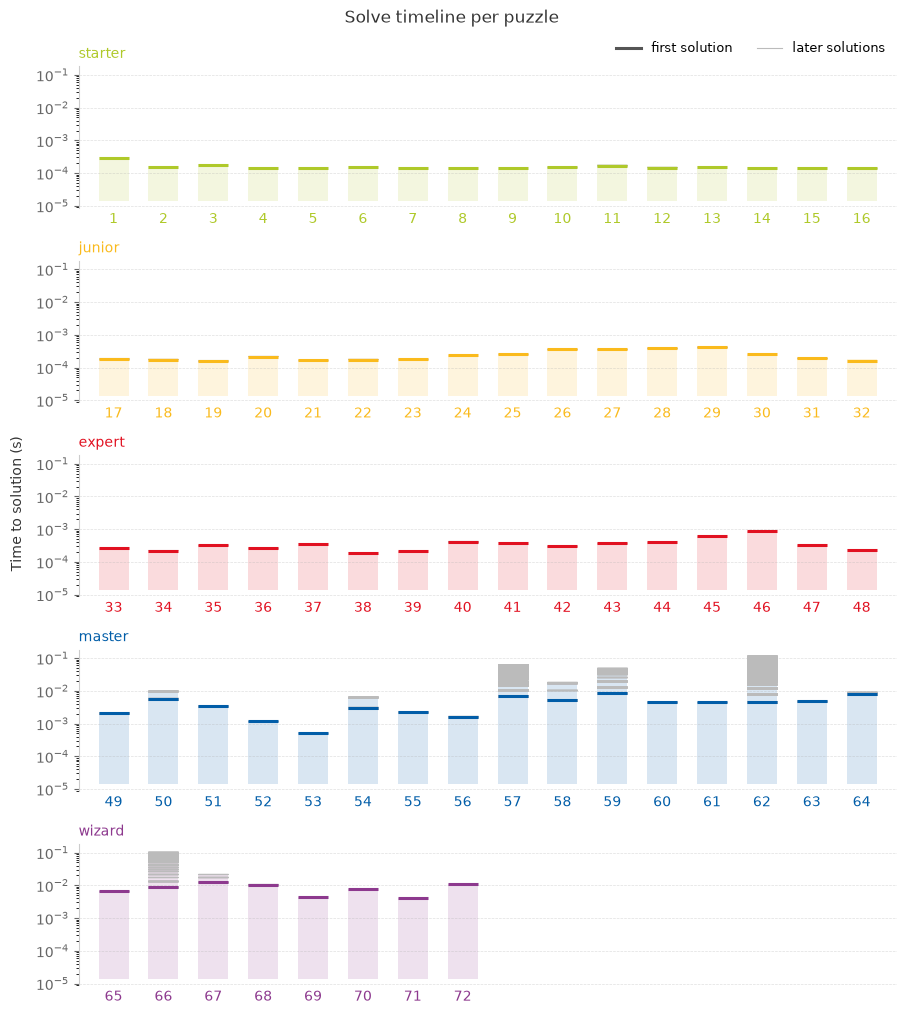

In [15]:
plot_solve_timeline(main_puzzles, main_stats)
plt.show()

The more pieces a puzzle places for you, the fewer ways are left to finish it. Plotting the number of solutions
against the number of pre-filled cells shows how the tiers are built: *starter* puzzles leave one or two pieces to
place, *wizard* puzzles nine of the twelve. Within a tier, though, the number of solutions varies a lot.

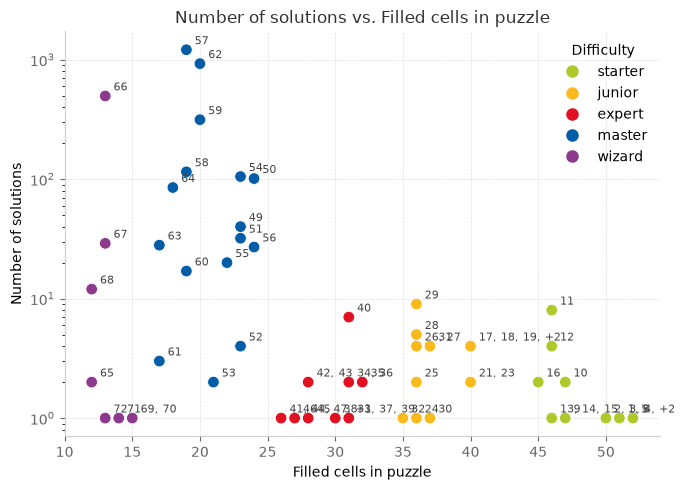

In [16]:
plot_puzzle_stats(main_puzzles, main_stats)
plt.show()

That raises the question this part is about: **how far could it go?** With a given number of pre-filled cells, how few
solutions can a puzzle have, and how many? Are there puzzles harder than the booklet's *wizards*, or unique ones with
even fewer pieces given?

## 4. The bounds

The answer comes from the **empty board**. Any puzzle is "some blocks fixed in place", and every solution of that
puzzle is also a solution of the empty board, one that happens to place those blocks the same way. So once we have
every solution of the empty board, the number of solutions of *any* puzzle is a count: how many empty-board solutions
agree with it on the fixed blocks.

`compute_puzzle_bounds` does exactly that. It groups the empty board's solutions by how they place each subset of
blocks, without calling the solver again. For every number of filled cells, it finds the puzzle with the fewest
solutions (the **lower bound**) and the one with the most (the **upper bound**). These are exact, not samples.

The bounds themselves are small, and they are part of the repository under `bounds/`, so we just load them:

In [17]:
(lower_puzzles, lower_stats), (upper_puzzles, upper_stats) = load_bounds(IQpuzzler, "main")

empty_stats = lower_stats["1"]   # each bound book starts at the empty board itself
print(f"The empty board has {len(empty_stats.elapsed):,} solutions (found in {empty_stats.duration:.1f} s).")

The empty board has 371,020 solutions (found in 71.5 s).


To compute the bounds yourself instead, run the block below (about two minutes). It finds every solution of the empty
board again, which is about a minute, then groups them and times each bound's puzzle. The empty board's solutions are
not saved: as JSON they would be a large file, and the bounds don't need them once computed. `save_bounds` overwrites
`bounds/IQpuzzler/main`.

In [18]:
# empty_solution, empty_stats = solve_puzzle(empty, verbose=Verbosity.SUMMARY)
# bounds = compute_puzzle_bounds(empty_solution, empty_stats, verbose=False)
# save_bounds(IQpuzzler, *bounds)
# (lower_puzzles, lower_stats), (upper_puzzles, upper_stats) = bounds

The band below is every attainable number of solutions, with the shaded areas unreachable. On top of it is the booklet
again:

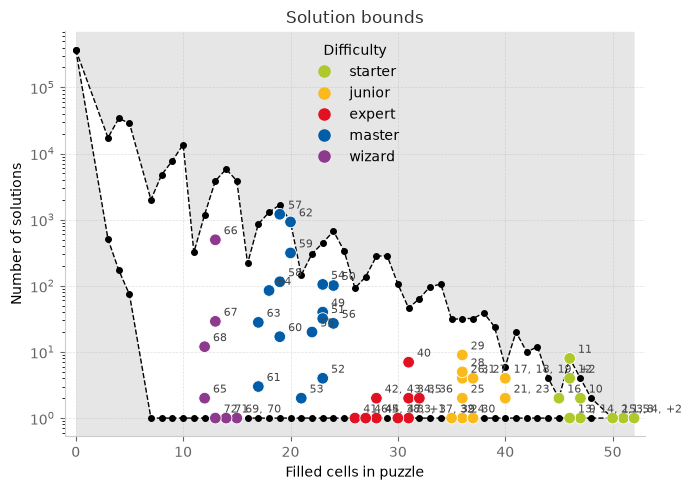

In [19]:
ax = plot_bounds(lower_puzzles, lower_stats, upper_puzzles, upper_stats)
plot_puzzle_stats(main_puzzles, main_stats, ax=ax)
plt.show()

The booklet sits well inside the band. From 7 filled cells on, the lower bound is 1 at every count: there is always a
puzzle with a unique solution. At the other edge, puzzle 62 touches the upper bound: its 925 solutions are the most any
puzzle with 20 filled cells can have.

## 5. How few pieces make a unique puzzle?

The lower bound answers the puzzle designer's question: **what is the fewest number of filled cells that can still pin
down a single solution?**

In [20]:
def by_filled(puzzles, stats):
    # (filled cells, number of solutions, puzzle) for each puzzle, by filled cells
    return sorted(((p.nr_filled_cells, len(stats[name].elapsed), p) for name, p in puzzles.items()), key=lambda e: e[:2])

lower = by_filled(lower_puzzles, lower_stats)
book = by_filled(main_puzzles, main_stats)

fewest_unique = next(entry for entry in lower if entry[1] == 1)
book_fewest_unique = next(entry for entry in book if entry[1] == 1)
print(f"Fewest filled cells for a unique solution: {fewest_unique[0]} (the booklet's fewest: {book_fewest_unique[0]}, puzzle {book_fewest_unique[2].name})")
print(fewest_unique[2].copy(rename=f"with the fewest solutions at {fewest_unique[0]} filled cells"))

Fewest filled cells for a unique solution: 7 (the booklet's fewest: 13, puzzle 72)
Puzzle with the fewest solutions at 7 filled cells

 ┏━━━━━━━━━━━━━━━━━━━━━━┓ 
 ┃A                     ┃ 
 ┃A                     ┃ 
 ┃A A                   ┃ 
 ┃            F F       ┃ 
 ┃              F       ┃ 
 ┗━━━━━━━━━━━━━━━━━━━━━━┛ 

B B   C C   D     E     G G G   H       I I   J   K K     L   
B B   C     D D   E     G       H H       I   J   K K   L L L 
  B   C     D     E E   G         H H   I I   J           L   
      C     D       E                         J               


Two pieces are enough. With just `A` and `F` placed like this, there is exactly one way to fit the other ten, while the
booklet's most open unique puzzle still gives away 13 cells. Anything with fewer filled cells, a single piece or
none, has at least 74 solutions.

# Part II: IQpuzzlerPRO

## 6. Other boards, same solver

IQpuzzlerPRO has a new set of 12 blocks and three boards. One is the familiar 11 x 5 rectangle, one is a diagonal
*alt* board, and one is a **pyramid**, 5 layers of 5x5, 4x4, ... 1x1 cells, where pieces can also lie in the pyramid's tilted planes.

In [21]:
print(IQpuzzlerPRO.puzzles["empty_main"])
for key in ["alt", "pyramid"]:
    board = IQpuzzlerPRO.puzzles[f"empty_{key}"]
    print(board.setup.render(board.grid, header=key))

Puzzle empty_main

 ┏━━━━━━━━━━━━━━━━━━━━━━┓ 
 ┃                      ┃ 
 ┃                      ┃ 
 ┃                      ┃ 
 ┃                      ┃ 
 ┃                      ┃ 
 ┗━━━━━━━━━━━━━━━━━━━━━━┛ 

A       B     C C   D     E     F       G G G   H       I I   J J   K     L L L 
A A     B B   C     D D   E     F F     G       H         I   J J   K K   L   L 
A     B B     C       D   E E     F F           H H H         J     K           
A             C             E                                                   
alt

   ┏━━━━━━━━┓         
 ┏━┛        ┃         
 ┃          ┗━━━┓     
 ┃              ┃     
 ┃              ┗━━━┓ 
 ┃                  ┃ 
 ┗━━━┓              ┃ 
     ┃              ┃ 
     ┗━━━┓          ┃ 
         ┃        ┏━┛ 
         ┗━━━━━━━━┛   
pyramid

layer 0         layer 1         layer 2         layer 3         layer 4       
 ┏━━━━━━━━━━┓    ┏━━━━━━━━┓      ┏━━━━━━┓        ┏━━━━┓          ┏━━┓         
 ┃          ┃    ┃        ┃      ┃      ┃ 

To the solver these are all the same thing. A board is a set of cells plus how its axes relate (`PyramidBoard` offsets
each layer by half a cell, `RegularBoard` doesn't). The `Setup` turns that geometry into the list of valid placements,
and from then on the search only sees cells and placements. Every board here happens to have 55 cells, but nothing
depends on that.

## 7. "Every puzzle has exactly one solution"

The box makes a promise the original game didn't keep: every one of its puzzles has a **unique** solution. Let's check all
three PRO booklets, with the two IQpuzzler ones for comparison:

In [22]:
books = {
    ("IQpuzzler", "main_puzzles"): IQpuzzler.books["main_puzzles"],
    ("IQpuzzler", "pyramid_puzzles"): IQpuzzler.books["pyramid_puzzles"],
    ("IQpuzzlerPRO", "main_puzzles"): IQpuzzlerPRO.books["main_puzzles"],
    ("IQpuzzlerPRO", "alt_puzzles"): IQpuzzlerPRO.books["alt_puzzles"],
    ("IQpuzzlerPRO", "pyramid_puzzles"): IQpuzzlerPRO.books["pyramid_puzzles"],
}
results = {key: solve_puzzlebook(book) for key, book in books.items()}

print(f"{'game':<14}{'book':<17}{'puzzles':>8}{'unique':>8}   not unique")
for (game, name), (solutions, _) in results.items():
    multiple = {p: len(s) for p, s in solutions.items() if len(s) > 1}
    shown = ", ".join(f"{p}: {n}" for p, n in multiple.items()) if len(multiple) <= 8 else f"{len(multiple)} puzzles"
    print(f"{game:<14}{name:<17}{len(solutions):>8}{len(solutions) - len(multiple):>8}   {shown}")

game          book              puzzles  unique   not unique
IQpuzzler     main_puzzles           72      29   43 puzzles
IQpuzzler     pyramid_puzzles        29      22   85: 2, 89: 2, 92: 2, 95: 2, 98: 2, 100: 6, 101: 3
IQpuzzlerPRO  main_puzzles           40      40   
IQpuzzlerPRO  alt_puzzles            40      40   
IQpuzzlerPRO  pyramid_puzzles        40      39   120: 5


The promise holds on the flat boards: all 80 main and alt puzzles are unique. On the pyramid it holds for 39 of 40,
and **puzzle 120** has 5 solutions:

In [23]:
pro_pyramid = IQpuzzlerPRO.books["pyramid_puzzles"]
pro_pyramid_solutions, pro_pyramid_stats = results[("IQpuzzlerPRO", "pyramid_puzzles")]
print(pro_pyramid["120"])
print(pro_pyramid_solutions["120"])

Puzzle 120

layer 0         layer 1         layer 2         layer 3         layer 4       
 ┏━━━━━━━━━━┓    ┏━━━━━━━━┓      ┏━━━━━━┓        ┏━━━━┓          ┏━━┓         
 ┃          ┃    ┃        ┃      ┃      ┃        ┃    ┃          ┃  ┃         
 ┃      A   ┃    ┃        ┃      ┃      ┃        ┃    ┃          ┗━━┛         
 ┃  A A A A ┃    ┃        ┃      ┃      ┃        ┗━━━━┛                       
 ┃          ┃    ┃        ┃      ┗━━━━━━┛                                     
 ┃          ┃    ┗━━━━━━━━┛                                                   
 ┗━━━━━━━━━━┛                                                                 

  B     C C   D     E     F       G G G   H       I I   J J   K     L L L 
  B B   C     D D   E     F F     G       H         I   J J   K K   L   L 
B B     C       D   E E     F F           H H H         J     K           
        C             E                                                   
Puzzle 120 (solution 1)

layer 0         layer 1       

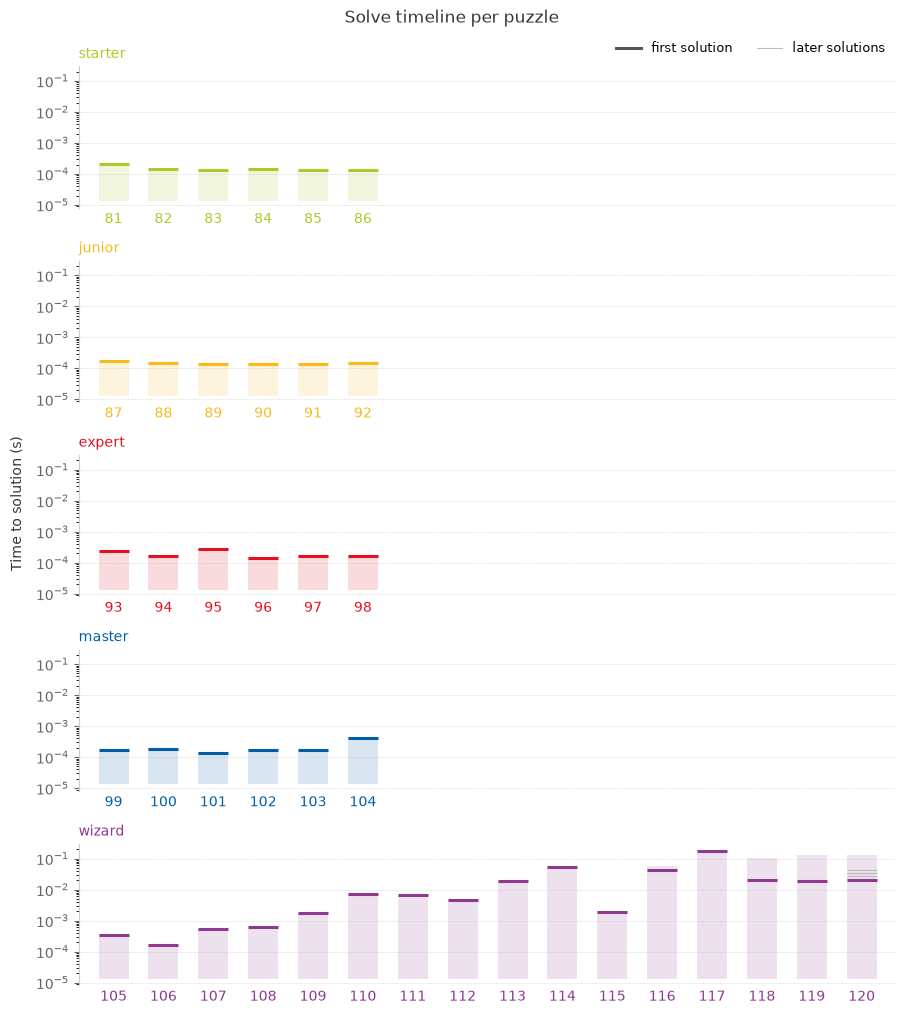

In [24]:
plot_solve_timeline(pro_pyramid, pro_pyramid_stats)
plt.show()

This isn't the solver's mistake. `tests/data/IQpuzzlerPRO/` holds the booklet's printed solution for every PRO
puzzle, entered and checked by hand. `tests/test_solver.py` asserts that the solver finds that solution and no other,
except for pyramid 120, where it finds the printed one and four more. Each of the five can be checked by eye above.

# Summary

- An exact-cover search that always branches on the scarcest cell *or* block finds every solution of every booklet
  puzzle in milliseconds, and of a whole booklet in under a second.
- Only 29 of the original IQpuzzler's 72 booklet puzzles have a unique solution. Master puzzle 57 has 1,209.
- The empty board has 371,020 solutions. From them come exact bounds for every number of filled cells: two pieces
  (7 cells) can already force a unique solution, while the booklet never gives away fewer than 13 cells for one.
  Puzzle 62 is as open as a 20-cell puzzle can be.
- IQpuzzlerPRO keeps its promise on the flat boards, with all 80 puzzles unique. On the pyramid, puzzle 120 has five
  solutions. The original IQpuzzler's pyramid booklet has 7 of 29 non-unique.